# Notebook 05a: Signed-laterality decodability probe (Idea 5, core arm)

This notebook reifies the core, zero-retrain arm of research idea 5,
[signed-laterality-decodability](notes/ideas-claude/05-signed-laterality-decodability/README.md).
It asks one falsifiable question on the frozen `d0acc262` Skeleton-JEPA (S-JEPA) checkpoint:

> On source-video-disjoint folds, is a signed left-minus-right laterality axis linearly decodable
> from the frozen S-JEPA token tensor above a raw-coordinate null by a pre-registered margin, and
> does the anatomical mirror that swaps left and right landmarks negate the decoded scalar?

Nothing here retrains the encoder. Every lane is a test-time linear read of already-cached frozen
target-encoder tokens. The notebook is written to run in two modes:

- `GAVD_MODE=real`: reads the real pose cache and the `d0acc262` checkpoint, exactly as notebooks
  05 and 06 do.
- `GAVD_MODE=smoke` (default when artifacts are absent): builds a small synthetic cohort with a
  planted, sign-flipping laterality signal so every cell runs end to end and the plots render. Smoke
  numbers are illustrative only and are labelled as such.

All results are TRANSDUCTIVE: the encoder saw the evaluation rows during training. The source video
is the independent unit, and folder labels (stroke, parkinsons) are dataset annotations, not
diagnoses. See `notes/ideas-claude/_shared_facts.md` for the single source of truth on every number.

## Reader's guide: the big ideas in everyday language

No background in machine learning is assumed here. This guide defines the terms used throughout
the notebook before any scores are interpreted.

### What goes into the experiment, and what comes out?

A **pose sequence** is a short time-ordered series of body-joint coordinates: where the left wrist,
right wrist, shoulders, hips, and other landmarks are in each video frame. The **encoder** is the
part of S-JEPA that turns those coordinates into a long list of learned numbers called **features**
or a **representation**. A feature need not have a human-readable meaning; it is simply a number the
model found useful while learning. **Frozen encoder** means those learned numbers are produced by an
already-trained encoder whose weights are not changed anywhere in this notebook.

The target is one **scalar**, meaning one number per pose sequence. It is **signed**: positive and
negative values represent opposite left-versus-right directions. Calling it a **laterality axis**
means that this one number summarizes a left-minus-right movement difference. It is not a diagnosis.

A **linear probe**, also called a **readout** or **decoder**, is a deliberately simple prediction rule
fitted on top of the frozen features. It multiplies each feature by a learned weight and adds the
results. To **decode** the target means to use that rule to turn the feature list back into one
predicted laterality number. If a linear probe works, the information is easy to read from the chosen
features; failure does not prove that no more complicated method could ever find it.

### What does R-squared mean, including a negative value?

**R-squared** (`R²`) compares the probe with a very simple fallback: ignore every input and always
predict the average target value in the held-out test data. `R² = 1` means perfect predictions.
`R² = 0` means the probe is no better than repeatedly predicting that average. **Negative R-squared**
means the probe makes larger squared errors than the average-only fallback. For example, if the true
values are 1, 2, and 3, always predicting their average, 2, is the baseline. A model whose predictions
miss those values by even more receives a negative R-squared. Negative does not mean 'negative
movement' or 'negative correlation'; it means 'worse predictive errors than the average baseline.'

### What is a gate?

A **gate** is a pass-or-fail checkpoint whose threshold was chosen before looking at the final result.
It works like a minimum requirement on a checklist. All three primary gates must pass before this
notebook calls the signed axis present. This protects against selecting whichever score happens to look
best after the fact. The mirror test and nuisance control are additional safeguards described below.

### What are decoded-original and decoded-mirrored?

**Decoded-original** is the number produced when an ordinary pose sequence goes through the encoder
and then through the fitted Lane A readout. **Decoded-mirrored** is the number produced by the same
encoder and the same readout after the input has been anatomically mirrored. The code mirrors a pose
by (1) negating its horizontal `x` coordinate and (2) swapping every left landmark with its matching
right landmark. No new mirror-specific readout is fitted. Thus the only intended difference between
the two decoded values is the mirror applied to the input.

If the original decoded value is `+2`, a perfectly behaving signed left-minus-right representation
should decode the mirror as about `-2`. Across many sequences, a plot with decoded-original on the
horizontal axis and decoded-mirrored on the vertical axis should follow the line `y = -x`. Its slope
would be `-1`. This equal-size, opposite-sign behavior is called **antisymmetry**.

### What is the mirror test?

The **mirror test** checks whether the model's decoded number changes in the expected way when left and
right are deliberately exchanged. It is not merely another accuracy score. A probe can predict the
target yet still rely on features that do not obey the expected left/right transformation. The test
therefore measures the organization of the information, not just whether some information is present.
A mirror slope in the pre-agreed band `[-1.25, -0.8]` counts as a sufficiently clean sign reversal.

### What is the clean nuisance control?

A **control** is a comparison designed to catch an alternative explanation. A **nuisance** is an
unwanted clue, such as overall movement size, video style, or pose-detector behavior, that might help
prediction without representing left versus right. Lane D deliberately removes explicit left/right
identity by pooling joints into global averages and standard deviations. It should therefore fail to
recover a genuinely signed left-minus-right value. Calling the nuisance control **clean** means Lane D
stays near zero and does not trigger the pre-defined artifact warning. This removes one specific
alternative explanation; it does not by itself make Lane A successful or prove that every possible
artifact has been eliminated.

### What do source-video-disjoint, transductive, and high-dimensional mean?

**Source-video-disjoint** means that all samples derived from one source video stay together: that
video is used either to fit the probe or to test it, never both. This reduces direct leakage between
the probe's training and test rows. However, the encoder itself had already learned from this corpus
before these probe splits were created. That setting is **transductive**: the readout is tested on
withheld videos, but the representation-maker has previously seen the overall evaluation collection.
A useful analogy is a student who studied the entire stack of cards before the teacher later separated
some cards into a quiz. The quiz still tests the final readout, but it does not demonstrate performance
on cards from a truly new person or dataset.

**High-dimensional** means there are many candidate feature numbers compared with the number of
independent examples. Here the learned lane has 1,152 feature columns but only 96 sequences from 18
source videos. A flexible fit can then find accidental patterns, and many columns may carry nearly the
same information. **Ridge regression** reduces this problem by discouraging extremely large weights,
but it cannot create more independent videos. High dimensionality makes exact scores less stable and
is one reason the baselines, held-out videos, fixed gates, and numerical-sensitivity checks matter.

## 0. Environment and mode

We resolve the project root the same way notebooks 04-06 do (via `ALEXPOSE_ROOT` or a `.git` +
`data/gavd` marker), load the `.env`, and decide the run mode. If the real artifacts are missing we
fall back to smoke mode instead of raising, so the notebook is always runnable.

In [1]:
from pathlib import Path
import os, sys, math, json, hashlib, copy, warnings

import numpy as np
import pandas as pd

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


def find_project_root(start=None):
    env_root = os.getenv("ALEXPOSE_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TUTORIAL_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd5"
try:
    from dotenv import load_dotenv
    load_dotenv(TUTORIAL_DIR / ".env", override=False)
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except Exception:
    pass

# Artifact locations follow the SAME env resolution as notebook 05 exactly:
#   ARTIFACT_ROOT = GAVD_ARTIFACT_DIR or TUTORIAL_DIR/work/artifacts
#   ARTIFACT_DIR  = ARTIFACT_ROOT / MODE   (checkpoints live directly here)
#   POSE_DIR      = ARTIFACT_DIR / "poses"
ARTIFACT_ROOT = Path(
    os.getenv("GAVD_ARTIFACT_DIR", TUTORIAL_DIR / "work" / "artifacts")
).expanduser()

REQUESTED_MODE = os.getenv("GAVD_MODE", "smoke").strip().lower()
if REQUESTED_MODE not in {"smoke", "real"}:
    raise ValueError("GAVD_MODE must be smoke or real")

# Checkpoint selection mirrors notebook 05: augmented cohort is the d0acc262 lineage.
TRUTHY = {"1", "true", "yes", "on"}
INCLUDE_AUGMENTED = os.getenv("SJEPA_INCLUDE_AUGMENTED_NORMAL", "1").strip().lower() in TRUTHY
EXPLICIT_CHECKPOINT = os.getenv("SJEPA_INSPECT_CHECKPOINT", "").strip()
CHECKPOINT_NAME = (
    "sjepa_curriculum_final_augmented.pt" if INCLUDE_AUGMENTED else "sjepa_curriculum_final.pt"
)
EXPECTED_FINGERPRINT_PREFIX = "d0acc262"
CONDITIONS = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]


def artifact_dir_for(mode):
    return ARTIFACT_ROOT / mode


def checkpoint_path_for(mode):
    if EXPLICIT_CHECKPOINT:
        p = Path(EXPLICIT_CHECKPOINT).expanduser()
        return p if p.is_absolute() else artifact_dir_for(mode) / p
    return artifact_dir_for(mode) / CHECKPOINT_NAME


# Real mode requires BOTH the real checkpoint and the real pose cache; else fall back to smoke.
real_ckpt = checkpoint_path_for("real")
real_poses = artifact_dir_for("real") / "poses"
have_real = REQUESTED_MODE == "real" and real_ckpt.is_file() and real_poses.exists()
MODE = "real" if have_real else "smoke"
if REQUESTED_MODE == "real" and not have_real:
    warnings.warn(
        f"Requested real mode but artifacts are missing "
        f"(checkpoint={real_ckpt.is_file()}, poses={real_poses.exists()}). "
        "Falling back to smoke mode with a synthetic cohort. Smoke numbers are illustrative only."
    )

ARTIFACT_DIR = artifact_dir_for(MODE)
POSE_DIR = ARTIFACT_DIR / "poses"
CHECKPOINT_PATH = checkpoint_path_for(MODE)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

if MODE == "smoke":
    print("SMOKE MODE: hand-authored motions test code paths only. No clinical validity.")
print(f"PROJECT_ROOT      : {PROJECT_ROOT}")
print(f"ARTIFACT_ROOT     : {ARTIFACT_ROOT}")
print(f"requested mode    : {REQUESTED_MODE}")
print(f"effective MODE    : {MODE}")
print(f"checkpoint        : {CHECKPOINT_PATH}  (present={CHECKPOINT_PATH.is_file()})")
print(f"pose cache        : {POSE_DIR}  (present={POSE_DIR.exists()})")

PROJECT_ROOT      : /Users/pmui/dev/alexpose
ARTIFACT_ROOT     : /Users/pmui/dev/alexpose/experiments/sjepa/gavd5/work/artifacts
requested mode    : real
effective MODE    : real
checkpoint        : /Users/pmui/dev/alexpose/experiments/sjepa/gavd5/work/artifacts/real/sjepa_curriculum_final_augmented.pt  (present=True)
pose cache        : /Users/pmui/dev/alexpose/experiments/sjepa/gavd5/work/artifacts/real/poses  (present=True)


## 1. Anatomy constants and the frozen laterality operators

These constants match notebooks 04-06 exactly. `MASK_KEYPOINTS` is the 12-landmark maskable whitelist.
`LEFT_RIGHT_PAIRS` is the six lower-body-plus-shoulder pair list used to build the anatomical mirror
and the signed target. We freeze two deterministic functions here BEFORE seeing any features:

- `signed_left_minus_right(coords)`: the regression target `y`. It is a translation-invariant, signed
  per-side excursion difference (left minus right). Positive leans left, negative leans right.
- `anatomical_mirror(coords)`: negates x and swaps each left landmark with its right partner. A clean
  antisymmetric (reflection-equivariant) encoding should negate the decoded scalar under this mirror.

Both operate on RAW coordinates (before the encoder), exactly as the proposal specifies.

In [2]:
BLAZEPOSE_33 = [
    "NOSE", "LEFT_EYE_INNER", "LEFT_EYE", "LEFT_EYE_OUTER", "RIGHT_EYE_INNER", "RIGHT_EYE",
    "RIGHT_EYE_OUTER", "LEFT_EAR", "RIGHT_EAR", "MOUTH_LEFT", "MOUTH_RIGHT", "LEFT_SHOULDER",
    "RIGHT_SHOULDER", "LEFT_ELBOW", "RIGHT_ELBOW", "LEFT_WRIST", "RIGHT_WRIST", "LEFT_PINKY",
    "RIGHT_PINKY", "LEFT_INDEX", "RIGHT_INDEX", "LEFT_THUMB", "RIGHT_THUMB", "LEFT_HIP", "RIGHT_HIP",
    "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE", "RIGHT_ANKLE", "LEFT_HEEL", "RIGHT_HEEL",
    "LEFT_FOOT_INDEX", "RIGHT_FOOT_INDEX",
]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]

# Lower-body-plus-shoulder pairs for the SIGNED target (proposal Method, code block).
LEFT_RIGHT_PAIRS = [(11, 12), (23, 24), (25, 26), (27, 28), (29, 30), (31, 32)]

# The FULL 16-pair mirror (matches notebook 05's geometric_view flip): every left/right landmark,
# including face and arm, so the mirror is a valid whole-body reflection.
FULL_MIRROR_PAIRS = [
    (1, 4), (2, 5), (3, 6), (7, 8), (9, 10),          # eyes, ears, mouth
    (11, 12), (13, 14), (15, 16), (17, 18), (19, 20), (21, 22),  # shoulder..thumb
    (23, 24), (25, 26), (27, 28), (29, 30), (31, 32),            # hip..foot index
]


def signed_left_minus_right(coords):
    '''coords: (T, 33, 3) or (T, 33, >=3). Signed per-side excursion, left minus right.'''
    coords = np.asarray(coords, dtype=np.float64)[..., :3]
    total = 0.0
    for left_idx, right_idx in LEFT_RIGHT_PAIRS:
        left_excursion = coords[:, left_idx, :].std(axis=0).sum()
        right_excursion = coords[:, right_idx, :].std(axis=0).sum()
        total += left_excursion - right_excursion
    return float(total)


def anatomical_mirror(coords, pairs=FULL_MIRROR_PAIRS):
    '''Negate x and swap each left landmark with its right partner. Preserves the visibility column
    if present so the mirrored sequence can go back through the same preprocessing.'''
    mirrored = np.asarray(coords, dtype=np.float32).copy()
    mirrored[:, :, 0] = -mirrored[:, :, 0]
    for left_idx, right_idx in pairs:
        mirrored[:, [left_idx, right_idx], :] = mirrored[:, [right_idx, left_idx], :]
    return mirrored


# Self-check: the target is antisymmetric on RAW coordinates by construction.
_demo = np.random.randn(20, 33, 3).astype(np.float32)
_orig = signed_left_minus_right(_demo)
_mir = signed_left_minus_right(anatomical_mirror(_demo))
print(f"raw-coordinate self-check:  original={_orig:+.4f}  mirrored={_mir:+.4f}  (should be near equal-and-opposite)")
assert abs(_orig + _mir) < 1e-6 * (1 + abs(_orig)), "raw target must be exactly antisymmetric"
print("OK: signed_left_minus_right is antisymmetric on raw coordinates.")

raw-coordinate self-check:  original=+1.4555  mirrored=-1.4555  (should be near equal-and-opposite)
OK: signed_left_minus_right is antisymmetric on raw coordinates.


## 2. Preprocessing (reused verbatim from notebooks 04-06)

To feed the encoder we reuse the project's exact preprocessing chain: short-gap interpolation,
pelvis-centering and body-scale normalization, and a temporal resize to 64 frames. These are copied
from notebook 05 so the tokens we cache are identical to what training and inspection produced.

A subtle but important point for the mirror arm: `center_and_scale` subtracts the pelvis and divides
by a body-scale, and `signed_left_minus_right` uses per-joint standard deviation (excursion), which is
translation-invariant. So the signed target is well defined either on raw or on centered coordinates.
We apply the mirror on the RAW coordinate column and then run the SAME preprocessing, so the mirrored
input the encoder sees is a genuine reflection of a real preprocessed sequence.

In [3]:
def interpolate_low_visibility(sequence, threshold=0.45, max_gap=4):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
        raise ValueError(f"Expected [T, 33, 4], received {sequence.shape}")
    visibility = np.nan_to_num(sequence[..., 3], nan=0.0)
    finite = np.isfinite(sequence[..., :3]).all(axis=-1)
    valid = (visibility >= threshold) & finite
    filled = valid.copy()
    for joint in range(33):
        observed = np.flatnonzero(valid[:, joint])
        for left, right in zip(observed[:-1], observed[1:]):
            gap = int(right - left - 1)
            if not 0 < gap <= max_gap:
                continue
            fraction = (np.arange(1, gap + 1, dtype=np.float32) / (gap + 1))[:, None]
            sequence[left + 1:right, joint, :3] = (
                sequence[left, joint, :3][None, :] * (1.0 - fraction)
                + sequence[right, joint, :3][None, :] * fraction)
            filled[left + 1:right, joint] = True
        sequence[~filled[:, joint], joint, :3] = np.nan
    sequence[..., 3] = visibility
    return sequence, valid


def center_and_scale(sequence, eps=1e-6):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    xyz = sequence[..., :3]
    left_hip, right_hip = xyz[:, 23], xyz[:, 24]
    left_ok = np.isfinite(left_hip).all(axis=1)
    right_ok = np.isfinite(right_hip).all(axis=1)
    pelvis = np.full((len(xyz), 3), np.nan, dtype=np.float32)
    both = left_ok & right_ok
    pelvis[both] = 0.5 * (left_hip[both] + right_hip[both])
    pelvis[left_ok & ~right_ok] = left_hip[left_ok & ~right_ok]
    pelvis[right_ok & ~left_ok] = right_hip[right_ok & ~left_ok]
    pelvis_ok = np.isfinite(pelvis).all(axis=1)
    fallback = np.median(pelvis[pelvis_ok], axis=0) if pelvis_ok.any() else np.zeros(3)
    pelvis[~np.isfinite(pelvis).all(axis=1)] = fallback
    xyz = xyz - pelvis[:, None, :]
    shoulder_width = np.linalg.norm(xyz[:, 11, :2] - xyz[:, 12, :2], axis=-1)
    hip_width = np.linalg.norm(xyz[:, 23, :2] - xyz[:, 24, :2], axis=-1)
    body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))
    if not np.isfinite(body_scale) or body_scale < eps:
        body_scale = 1.0
    sequence[..., :3] = np.nan_to_num(xyz / body_scale, nan=0.0, posinf=0.0, neginf=0.0)
    return np.nan_to_num(sequence, nan=0.0, posinf=0.0, neginf=0.0)


def temporal_resize(array, frames):
    array = np.asarray(array)
    if len(array) == frames:
        return array.copy()
    if len(array) < 2:
        return np.repeat(array, frames, axis=0)
    old_t = np.linspace(0.0, 1.0, len(array))
    new_t = np.linspace(0.0, 1.0, frames)
    flat = array.reshape(len(array), -1)
    resized = np.stack([np.interp(new_t, old_t, flat[:, i]) for i in range(flat.shape[1])], axis=1)
    return resized.reshape(frames, *array.shape[1:])


def prepare_sequence(raw_sequence, frames):
    '''raw_sequence: [T, 33, 4] (x, y, z, visibility). Returns (xyz [frames,33,3], valid [frames,33]).'''
    interpolated, valid = interpolate_low_visibility(raw_sequence)
    scaled = center_and_scale(interpolated)
    xyz = temporal_resize(scaled[..., :3], frames)
    valid_resized = temporal_resize(valid.astype(np.float32), frames) > 0.5
    return xyz.astype(np.float32), valid_resized


print("preprocessing helpers ready (interpolate -> center_and_scale -> temporal_resize).")

preprocessing helpers ready (interpolate -> center_and_scale -> temporal_resize).


## 3. Model classes (reused verbatim so `state_dict` keys match)

The S-JEPA classes are not packaged as a module in this project; every notebook pastes them inline.
We paste the same `SkeletonPatchEncoder`, `SkeletonPredictor`, and `SJEPAGait` here so that
`load_state_dict` on the `d0acc262` checkpoint matches key-for-key. We ALWAYS construct the model with
`SJEPAGait(**checkpoint["config"])`, reading whatever dimensions the checkpoint stored, never hardcoding
them, so the state dict matches regardless of the exact embed_dim or depth the run used.

If PyTorch is unavailable (for example a docs-only environment) we set `HAVE_TORCH=False` and the
learned-encoder lanes are skipped with a clear message; the raw-coordinate null and the target still
run so the methodology is demonstrable.

In [4]:
try:
    import torch
    from torch import nn
    HAVE_TORCH = True
except Exception as exc:  # pragma: no cover
    HAVE_TORCH = False
    print(f"PyTorch unavailable ({exc}); learned-encoder lanes will be skipped.")

if HAVE_TORCH:
    class SkeletonPatchEncoder(nn.Module):
        def __init__(self, frames=64, joints=33, coordinate_dim=3, segment_length=4,
                     embed_dim=64, depth=2, heads=4, dropout=0.0):
            super().__init__()
            self.frames, self.joints, self.coordinate_dim = frames, joints, coordinate_dim
            self.segment_length, self.embed_dim = segment_length, embed_dim
            self.segments = frames // segment_length
            self.patch_embed = nn.Linear(segment_length * coordinate_dim, embed_dim)
            self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
            self.joint_pos = nn.Parameter(torch.randn(joints, embed_dim) * 0.02)
            layer = nn.TransformerEncoderLayer(
                d_model=embed_dim, nhead=heads, dim_feedforward=embed_dim * 4,
                dropout=dropout, activation="gelu", batch_first=True, norm_first=True)
            self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
            self.norm = nn.LayerNorm(embed_dim)

        def patchify(self, x):
            batch = x.shape[0]
            if x.shape[1:] != (self.frames, self.joints, self.coordinate_dim):
                raise ValueError(f"Expected [B,{self.frames},{self.joints},{self.coordinate_dim}], got {tuple(x.shape)}")
            x = x.reshape(batch, self.segments, self.segment_length, self.joints, self.coordinate_dim)
            x = x.permute(0, 1, 3, 2, 4)
            x = x.flatten(3)
            return x  # [B, segments, joints, segment_length*coordinate_dim]

        def positioned_tokens(self, x):
            tokens = self.patch_embed(self.patchify(x))
            tokens = tokens + self.time_pos[None, :, None, :] + self.joint_pos[None, None, :, :]
            return tokens

        def forward(self, x, keep_mask=None):
            tokens = self.positioned_tokens(x)
            batch = tokens.shape[0]
            flat = tokens.reshape(batch, self.segments * self.joints, self.embed_dim)
            encoded = self.blocks(flat)
            return self.norm(encoded)

    class SkeletonPredictor(nn.Module):
        def __init__(self, segments, joints, encoder_dim=64, predictor_dim=64, depth=2, heads=4, dropout=0.0):
            super().__init__()
            self.segments, self.joints, self.predictor_dim = segments, joints, predictor_dim
            self.encoder_to_predictor = nn.Linear(encoder_dim, predictor_dim)
            self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
            nn.init.normal_(self.mask_token, std=0.02)
            self.time_pos = nn.Parameter(torch.randn(segments, predictor_dim) * 0.02)
            self.joint_pos = nn.Parameter(torch.randn(joints, predictor_dim) * 0.02)
            layer = nn.TransformerEncoderLayer(
                d_model=predictor_dim, nhead=heads, dim_feedforward=predictor_dim * 4,
                dropout=dropout, activation="gelu", batch_first=True, norm_first=True)
            self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
            self.norm = nn.LayerNorm(predictor_dim)
            self.output = nn.Linear(predictor_dim, encoder_dim)

        def forward(self, *args, **kwargs):
            raise NotImplementedError("Predictor is not needed for the frozen probe.")

    class SJEPAGait(nn.Module):
        def __init__(self, frames=64, joints=33, coordinate_dim=3, segment_length=4,
                     embed_dim=64, encoder_depth=2, predictor_depth=2, heads=4):
            super().__init__()
            self.view_encoder = SkeletonPatchEncoder(
                frames, joints, coordinate_dim, segment_length, embed_dim, encoder_depth, heads)
            self.target_encoder = copy.deepcopy(self.view_encoder)
            for parameter in self.target_encoder.parameters():
                parameter.requires_grad_(False)
            segments = frames // segment_length
            self.predictor = SkeletonPredictor(segments, joints, embed_dim, embed_dim, predictor_depth, heads)
            self.register_buffer("target_center", torch.zeros(embed_dim))

    print("model classes defined.")

model classes defined.


## 4. Bind to one checkpoint (`d0acc262`) or build a matched smoke encoder

In real mode we load the checkpoint with the same guards as notebook 05 (mode, mask whitelist,
curriculum completion, conditions seen), verify the `d0acc262` fingerprint prefix, and construct the
model from the stored config. In smoke mode we build a small randomly-initialized `SJEPAGait` so the
plumbing runs; the smoke encoder is NOT the trained model and its numbers are illustrative.

We also build the UNTRAINED-ENCODER FLOOR: a second, freshly random-initialized `SJEPAGait` of the
identical architecture. Lane C reads its features.

In [5]:
CHECKPOINT = None
FINGERPRINT = "smoke-random"
if HAVE_TORCH and MODE == "real":
    CHECKPOINT = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
    # The same guard set notebook 05 uses so we can never bind to the wrong lineage.
    if CHECKPOINT.get("mode") != MODE:
        raise ValueError(f"Checkpoint mode {CHECKPOINT.get('mode')} does not match {MODE}.")
    if CHECKPOINT.get("mask_keypoints") != MASK_KEYPOINTS:
        raise ValueError("Checkpoint mask whitelist does not match the 12-point set.")
    if not CHECKPOINT.get("curriculum_complete", False):
        raise ValueError("Checkpoint is not a completed progressive curriculum final.")
    if CHECKPOINT.get("conditions_seen") != CONDITIONS:
        raise ValueError(f"Unexpected curriculum order: {CHECKPOINT.get('conditions_seen')}.")
    FINGERPRINT = str(CHECKPOINT.get("dataset_fingerprint", ""))
    if not FINGERPRINT.startswith(EXPECTED_FINGERPRINT_PREFIX):
        warnings.warn(f"Fingerprint {FINGERPRINT[:12]} does not start with {EXPECTED_FINGERPRINT_PREFIX}.")
    config = CHECKPOINT["config"]
    model = SJEPAGait(**config)
    model.load_state_dict(CHECKPOINT["model_state"])
    model.eval()
    FRAMES = config["frames"]
    SEGMENT_LENGTH = config["segment_length"]
    EMBED_DIM = config["embed_dim"]
    print(f"Loaded d0acc262 lineage. fingerprint prefix: {FINGERPRINT[:12]}  config: {config}")
elif HAVE_TORCH:
    # Smoke: a small matched architecture just to exercise the pipeline.
    config = {"frames": 32, "joints": 33, "coordinate_dim": 3, "segment_length": 4,
              "embed_dim": 32, "encoder_depth": 1, "predictor_depth": 1, "heads": 4}
    torch.manual_seed(RANDOM_SEED)
    model = SJEPAGait(**config).eval()
    FRAMES, SEGMENT_LENGTH, EMBED_DIM = config["frames"], config["segment_length"], config["embed_dim"]
    print(f"Smoke encoder built (untrained). config: {config}")
else:
    FRAMES, SEGMENT_LENGTH, EMBED_DIM = 64, 4, 64  # documentary defaults; no encoder available.
    model = None

# Untrained-encoder floor model (Lane C): identical architecture, fresh random init.
floor_model = None
if HAVE_TORCH:
    torch.manual_seed(RANDOM_SEED + 1)
    floor_model = SJEPAGait(**config).eval()
    print("Untrained-encoder floor model built (fresh random init).")

SEGMENTS = FRAMES // SEGMENT_LENGTH
print(f"FRAMES={FRAMES}  SEGMENT_LENGTH={SEGMENT_LENGTH}  SEGMENTS={SEGMENTS}  EMBED_DIM={EMBED_DIM}")

Loaded d0acc262 lineage. fingerprint prefix: d0acc2628d13  config: {'frames': 64, 'joints': 33, 'coordinate_dim': 3, 'segment_length': 4, 'embed_dim': 96, 'encoder_depth': 4, 'predictor_depth': 2, 'heads': 4}
Untrained-encoder floor model built (fresh random init).
FRAMES=64  SEGMENT_LENGTH=4  SEGMENTS=16  EMBED_DIM=96


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_14548/1238810217.py:23: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_14548/1238810217.py:59: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)


## 5. Build the cohort with provenance and source-video tags

In real mode we read the `.npz` pose cache exactly as notebook 05's `pose_records_from_cache` does,
keeping the raw `[T, 33, 4]` sequence, `video_id`, `condition`, and `sequence_id`. Provenance
(canonical vs augmented) is NOT a stored column, so we tag it structurally: records read from the
canonical `poses/` folder are canonical. The primary comparison later runs on the canonical-only
subset, because most normal rows come from the augmented extraction path and a naive contrast could
learn acquisition differences.

In smoke mode we reuse the project's canonical `synthetic_gait_sequence` / `synthetic_corpus` (the
same fixtures notebook 05 uses) and then add ONE clearly-labelled overlay: a per-source signed lateral
lean whose direction alternates by source and whose magnitude is set by the mechanism axis (lateralized
conditions lean; symmetric conditions do not). This planted lean is the only thing that makes the
smoke signed target non-degenerate, so the probe has a genuine sign to recover and the mirror has a
genuine sign to flip. It is a plumbing signal, not physiology.

In [6]:
FRAMES_SMOKE = 64  # matches the project synthetic fixtures


def synthetic_gait_sequence(condition="normal", frames=64, seed=0):
    '''Code-path fixture copied from notebook 05 (NOT a disease simulation).'''
    rng = np.random.default_rng(seed)
    phase = np.linspace(0.0, 4.0 * np.pi, frames, endpoint=False)
    seq = np.zeros((frames, 33, 4), dtype=np.float32)
    seq[..., 3] = 1.0
    base = {11: (0.42, 0.28), 12: (0.58, 0.28), 23: (0.45, 0.52), 24: (0.55, 0.52),
            25: (0.44, 0.70), 26: (0.56, 0.70), 27: (0.43, 0.89), 28: (0.57, 0.89),
            29: (0.42, 0.92), 30: (0.58, 0.92), 31: (0.39, 0.94), 32: (0.61, 0.94)}
    for joint, (x, y_) in base.items():
        seq[:, joint, 0] = x
        seq[:, joint, 1] = y_
    amplitude, lift = 0.045, 0.025
    if condition == "parkinsons":
        amplitude *= 0.45
        lift *= 0.45
    if condition == "myopathic":
        seq[:, [11, 12], 0] += 0.03 * np.sin(phase)[:, None]
        seq[:, [23, 24], 0] += 0.018 * np.sin(phase)[:, None]
    for joint, knee, foot, offset in [(27, 25, 31, 0.0), (28, 26, 32, np.pi)]:
        wave = np.sin(phase + offset)
        if condition == "stroke" and joint == 27:
            wave = 0.35 * wave
        if condition == "cerebralpalsy":
            seq[:, knee, 1] -= 0.045
            seq[:, joint, 1] -= 0.02
        seq[:, joint, 0] += amplitude * wave
        seq[:, knee, 0] += 0.4 * amplitude * wave
        seq[:, foot, 0] += amplitude * wave
        seq[:, joint, 1] -= lift * np.maximum(wave, 0.0)
        seq[:, foot, 1] -= 0.7 * lift * np.maximum(wave, 0.0)
    seq[..., :3] += rng.normal(0.0, 0.0025, seq[..., :3].shape)
    return seq


# Mechanism axis for the SMOKE lean overlay only: lateralized conditions carry a signed lean;
# symmetric/normal carry none. This is the built-in negative control in miniature.
SMOKE_LEAN_MAGNITUDE = {"stroke": 1.0, "cerebralpalsy": 0.8, "parkinsons": 0.5,
                        "myopathic": 0.0, "normal": 0.0}


def plant_signed_lean(seq, sign, magnitude, seed):
    '''Overlay a signed per-side excursion difference on a synthetic fixture (smoke only).'''
    if magnitude == 0.0 or sign == 0:
        return seq
    rng = np.random.default_rng(seed)
    out = seq.copy()
    phase = np.linspace(0.0, 4.0 * np.pi, len(seq), endpoint=False)
    for left_idx, right_idx in LEFT_RIGHT_PAIRS:
        gain = 0.03 * magnitude * sign * rng.uniform(0.8, 1.2)
        out[:, left_idx, 0] += gain * np.sin(phase)
        out[:, right_idx, 0] -= gain * np.sin(phase)
    return out


def synthesize_smoke_cohort(clips_per_source=3, frames=FRAMES_SMOKE):
    '''Two SOURCES per condition (so GroupKFold has disjoint sources), alternating lean sign.'''
    records = []
    counter = 0
    for condition in CONDITIONS:
        for source in range(2):
            sign = 1 if source == 0 else -1
            mag = SMOKE_LEAN_MAGNITUDE[condition]
            for clip in range(clips_per_source):
                base = synthetic_gait_sequence(condition=condition, frames=frames, seed=RANDOM_SEED + counter)
                seq = plant_signed_lean(base, sign, mag, seed=RANDOM_SEED + 1000 + counter)
                records.append({
                    "condition": condition,
                    "sequence_id": f"smoke_{condition}_{source}_{clip:02d}",
                    "video_id": f"smoke_source_{condition}_{source}",
                    "raw": seq, "provenance": "canonical",
                })
                counter += 1
    return records


def pose_records_from_cache(pose_dir, conditions):
    '''Read the real .npz cache the way notebook 05 does; tolerate optional fields.'''
    records = []
    for condition in conditions:
        folder = Path(pose_dir) / condition
        if not folder.exists():
            continue
        for path in sorted(folder.glob("*.npz")):
            data = np.load(path, allow_pickle=False)
            sequence = data["sequence"].astype(np.float32)  # [T, 33, 4]
            if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
                raise ValueError(f"Bad pose shape in {path}: {sequence.shape}")
            records.append({
                "condition": condition,
                "sequence_id": str(data["sequence_id"].item()),
                "video_id": str(data["video_id"].item()),
                "raw": sequence,
                # Provenance is not a stored column; canonical poses/ folder => canonical.
                "provenance": "canonical",
            })
    return records


if MODE == "real":
    records = pose_records_from_cache(POSE_DIR, CONDITIONS)
    print(f"real cohort: {len(records)} sequences from {len({r['video_id'] for r in records})} source videos")
else:
    records = synthesize_smoke_cohort()
    print(f"smoke cohort: {len(records)} synthetic sequences from {len({r['video_id'] for r in records})} sources")

meta = pd.DataFrame([{k: r[k] for k in ("condition", "sequence_id", "video_id", "provenance")} for r in records])
print(meta.groupby(["condition"]).size().to_string())
if len({r["video_id"] for r in records}) < 2:
    raise ValueError("Need at least two source videos for a source-disjoint split.")

real cohort: 96 sequences from 18 source videos
condition
cerebralpalsy    16
myopathic        47
normal           12
parkinsons        9
stroke           12


## 6. Compute the frozen target `y` and cache the four feature lanes

For every sequence we compute:

- `y` = `signed_left_minus_right` on the preprocessed coordinates (frozen before any fit).
- Lane A (learned probe): flattened per-token features from the frozen `d0acc262` target encoder over
  the 12 maskable landmarks (a laterality-structured feature vector).
- Lane B (raw-coordinate null, the fair ceiling): handcrafted signed per-pair excursion features, no
  network.
- Lane C (untrained-encoder floor): the same per-token features from a random-init encoder.
- Lane D (mean/std-pooled nuisance control): global mean and std over tokens, which is
  permutation-invariant and side-agnostic and so must NOT recover a signed axis.

We also cache the MIRRORED Lane A features (encoder run on the anatomically mirrored input) for the
equivariance test in section 8.

In [7]:
def encoder_tokens(enc_model, xyz_batch):
    '''xyz_batch: [B, FRAMES, 33, 3] float32. Returns [B, SEGMENTS, 33, EMBED_DIM] numpy.'''
    with torch.no_grad():
        x = torch.tensor(xyz_batch, dtype=torch.float32)
        tok = enc_model.target_encoder(x).reshape(len(xyz_batch), SEGMENTS, 33, EMBED_DIM)
    return tok.cpu().numpy()


def laterality_feature_from_tokens(tokens):
    '''tokens: [SEGMENTS, 33, D]. Build a signed, side-structured feature vector: for each L/R pair,
    concatenate the time-mean of the LEFT token and RIGHT token and their difference, over the 12
    maskable landmarks. This gives the linear probe explicit access to a per-side contrast.'''
    feats = []
    for left_idx, right_idx in LEFT_RIGHT_PAIRS:
        l = tokens[:, left_idx, :].mean(axis=0)
        r = tokens[:, right_idx, :].mean(axis=0)
        feats.append(l - r)            # signed contrast
        feats.append(l + r)            # symmetric part (context)
    return np.concatenate(feats)


def raw_null_feature(xyz):
    '''Lane B handcrafted signed features: per-pair signed excursion difference on the three axes.'''
    feats = []
    for left_idx, right_idx in LEFT_RIGHT_PAIRS:
        l = xyz[:, left_idx, :].std(axis=0)
        r = xyz[:, right_idx, :].std(axis=0)
        feats.append(l - r)            # 3 numbers per pair, signed
    return np.concatenate(feats)


def pooled_nuisance_feature(tokens):
    '''Lane D: global mean and std over ALL joint-time tokens (permutation-invariant, side-agnostic).'''
    flat = tokens.reshape(-1, tokens.shape[-1])
    return np.concatenate([flat.mean(axis=0), flat.std(axis=0)])


# Prepare all sequences, compute y and the raw null; batch the encoder passes.
prepared = [prepare_sequence(r["raw"], FRAMES) for r in records]
xyz_all = np.stack([p[0] for p in prepared]).astype(np.float32)  # [N, FRAMES, 33, 3]
y = np.array([signed_left_minus_right(x) for x in xyz_all], dtype=np.float64)
B_raw = np.stack([raw_null_feature(x) for x in xyz_all])

# Mirrored inputs (apply mirror on the RAW column, then the SAME preprocessing).
prepared_mir = [prepare_sequence(anatomical_mirror(r["raw"]), FRAMES) for r in records]
xyz_mir = np.stack([p[0] for p in prepared_mir]).astype(np.float32)

if HAVE_TORCH:
    def batched_tokens(enc, arr, bs=16):
        out = []
        for i in range(0, len(arr), bs):
            out.append(encoder_tokens(enc, arr[i:i + bs]))
        return np.concatenate(out)

    tokA = batched_tokens(model, xyz_all)
    tokA_mir = batched_tokens(model, xyz_mir)
    tokC = batched_tokens(floor_model, xyz_all)
    A_learned = np.stack([laterality_feature_from_tokens(t) for t in tokA])
    A_learned_mir = np.stack([laterality_feature_from_tokens(t) for t in tokA_mir])
    C_floor = np.stack([laterality_feature_from_tokens(t) for t in tokC])
    D_pooled = np.stack([pooled_nuisance_feature(t) for t in tokA])
    print(f"feature widths -> A:{A_learned.shape[1]}  B:{B_raw.shape[1]}  C:{C_floor.shape[1]}  D:{D_pooled.shape[1]}")
else:
    A_learned = A_learned_mir = C_floor = D_pooled = None
    print("No torch: only Lane B (raw null) and the target y are available.")

print(f"y stats: mean={y.mean():+.4f} std={y.std():.4f}  n={len(y)}")

feature widths -> A:1152  B:18  C:1152  D:192
y stats: mean=+0.5672 std=3.4761  n=96


## 7. Fit the four lanes with source-video-disjoint ridge probes

The split is stated before any fit: folds are SOURCE-VIDEO-DISJOINT via `GroupKFold` on `video_id`.
In plain language, every sequence from one source video stays on one side of a fold; no source video
can contribute rows to both the probe-fitting side and the scoring side. We pool signed laterality
across all conditions because some individual conditions have only one source, which is too little for
a meaningful leave-one-source-out estimate. The ridge penalty controls how large the fitted feature
weights may become. It is chosen only from the training sources inside each fold, so held-out sources
never influence that choice. We report held-out-source R-squared and mean absolute error per lane.

In [8]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error

ALPHAS = np.logspace(-3, 3, 13)
groups = meta["video_id"].to_numpy()
n_groups = len(np.unique(groups))
n_splits = max(2, min(5, n_groups))


def source_disjoint_probe(X, y, groups, n_splits):
    '''Held-out-source R2 and MAE with an inner alpha choice on training sources only.'''
    gkf = GroupKFold(n_splits=n_splits)
    preds = np.full(len(y), np.nan)
    for train_idx, test_idx in gkf.split(X, y, groups):
        # Inner selection of alpha on the training sources only.
        inner_groups = groups[train_idx]
        best_alpha, best_score = ALPHAS[0], -np.inf
        if len(np.unique(inner_groups)) >= 2:
            inner = GroupKFold(n_splits=min(3, len(np.unique(inner_groups))))
            for a in ALPHAS:
                scores = []
                for itr, iva in inner.split(X[train_idx], y[train_idx], inner_groups):
                    sc = StandardScaler().fit(X[train_idx][itr])
                    mdl = Ridge(alpha=a).fit(sc.transform(X[train_idx][itr]), y[train_idx][itr])
                    scores.append(r2_score(y[train_idx][iva], mdl.predict(sc.transform(X[train_idx][iva]))))
                if np.mean(scores) > best_score:
                    best_score, best_alpha = np.mean(scores), a
        sc = StandardScaler().fit(X[train_idx])
        mdl = Ridge(alpha=best_alpha).fit(sc.transform(X[train_idx]), y[train_idx])
        preds[test_idx] = mdl.predict(sc.transform(X[test_idx]))
    ok = ~np.isnan(preds)
    return {"r2": float(r2_score(y[ok], preds[ok])), "mae": float(mean_absolute_error(y[ok], preds[ok])),
            "preds": preds}


lanes = {}
lanes["B_raw_null"] = source_disjoint_probe(B_raw, y, groups, n_splits)
if HAVE_TORCH:
    lanes["A_learned"] = source_disjoint_probe(A_learned, y, groups, n_splits)
    lanes["C_floor"] = source_disjoint_probe(C_floor, y, groups, n_splits)
    lanes["D_pooled"] = source_disjoint_probe(D_pooled, y, groups, n_splits)

lane_table = pd.DataFrame([{"lane": k, "R2": v["r2"], "MAE": v["mae"]} for k, v in lanes.items()])
print(lane_table.to_string(index=False))

/Users/pmui/dev/alexpose/experiments/sjepa/gavd5/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.932455427957393e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.851632968121521e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.521244617057164e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned 

      lane        R2      MAE
B_raw_null  1.000000 0.000062
 A_learned -0.187133 2.559879
   C_floor  0.147138 2.206040
  D_pooled -0.014068 2.223385


/Users/pmui/dev/alexpose/experiments/sjepa/gavd5/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.396690217982723e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.451342323046447e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.350088562115161e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned 

## 8. Mirror-equivariance test

To **decode** means to turn encoder features into one predicted signed number with the Lane A readout.
**Decoded-original** is that prediction for the ordinary pose. **Decoded-mirrored** is the prediction
from the SAME readout after the pose's horizontal coordinate is negated and every left/right landmark
pair is swapped. For example, an original prediction of `+2` should become about `-2` after mirroring.
The Lane A probe is refit here on all sources only to provide one common readout for inspecting this
geometry; the actual decodability verdict still comes from section 7's held-out fits. A clean
equal-size, opposite-sign response is called antisymmetry and lands on `y = -x`. We report the slope
of decoded-mirrored versus decoded-original; a "flips" verdict needs that slope to fall in the
pre-agreed band [-1.25, -0.8].

In [9]:
mirror = {"available": False}
if HAVE_TORCH:
    sc = StandardScaler().fit(A_learned)
    probe = Ridge(alpha=1.0).fit(sc.transform(A_learned), y)
    dec_orig = probe.predict(sc.transform(A_learned))
    dec_mir = probe.predict(sc.transform(A_learned_mir))
    # slope of dec_mir vs dec_orig through the origin-agnostic least squares
    slope = float(np.polyfit(dec_orig, dec_mir, 1)[0])
    flips = (-1.25 <= slope <= -0.8)
    mirror = {"available": True, "slope": slope, "flips": bool(flips),
              "dec_orig": dec_orig, "dec_mir": dec_mir}
    print(f"mirror slope = {slope:+.3f}   verdict: {'FLIPS (antisymmetric)' if flips else 'DOES NOT FLIP'}")
else:
    print("No torch: mirror test skipped (needs the encoder).")

mirror slope = -0.343   verdict: DOES NOT FLIP


## 9. Pre-registered verdict

A **gate** is a pre-agreed pass-or-fail checkpoint. The learned probe (Lane A) passes only if all three
gates hold at once:

1. beats the untrained-encoder floor (Lane C) by at least 0.05 R-squared,
2. reaches at least 80 percent of the raw-coordinate null (Lane B) R-squared,
3. the decoded sign is consistent on at least 75 percent of held-out sources.

Missing any of gates 1-3 is scored as an **informative null**: a planned negative result that rules
out this particular hypothesis under this test, rather than an experiment with no interpretable answer.
Two safeguards are reported alongside those three primary gates. The **mirror gate** passes only when
the decoded-mirrored-versus-decoded-original slope lies in `[-1.25, -0.8]`. The **Lane D nuisance
control** passes when its R-squared is within 0.05 of zero in either direction, or is less than half of
Lane B's R-squared. In plain language, Lane D must predict poorly or remain far below the recoverable
raw-coordinate signal. A mirror failure withholds the antisymmetry claim. A Lane D failure triggers the
artifact warning and withdraws the signed interpretation even if the attractive scores look positive.
Together, these checks form the Day-14 decision rule from the proposal.

In [10]:
def sign_consistency(preds, y_true, groups):
    '''Fraction of held-out SOURCES whose median predicted sign matches the median true sign.'''
    frac = []
    for g in np.unique(groups):
        m = groups == g
        if np.isnan(preds[m]).all():
            continue
        ps = np.sign(np.nanmedian(preds[m]))
        ts = np.sign(np.median(y_true[m]))
        if ts == 0:  # symmetric source: count as correct if prediction is also near zero
            frac.append(1.0 if abs(np.nanmedian(preds[m])) <= 0.5 * np.std(y_true) else 0.0)
        else:
            frac.append(1.0 if ps == ts else 0.0)
    return float(np.mean(frac)) if frac else float("nan")


verdict = {"mode": MODE, "fingerprint": FINGERPRINT}
if HAVE_TORCH:
    a, b, c = lanes["A_learned"]["r2"], lanes["B_raw_null"]["r2"], lanes["C_floor"]["r2"]
    d = lanes["D_pooled"]["r2"]
    signcon = sign_consistency(lanes["A_learned"]["preds"], y, groups)
    beats_floor = (a - c) >= 0.05
    reaches_null = a >= 0.80 * max(b, 1e-9)
    sign_ok = signcon >= 0.75
    passed = bool(beats_floor and reaches_null and sign_ok)
    verdict.update({
        "A_r2": a, "B_r2": b, "C_r2": c, "D_r2": d, "sign_consistency": signcon,
        "beats_floor_by_0.05": bool(beats_floor), "reaches_80pct_of_null": bool(reaches_null),
        "sign_consistent_75pct": bool(sign_ok),
        "mirror_slope": mirror.get("slope"), "mirror_flips": mirror.get("flips"),
        "PRIMARY_VERDICT": "SIGNED AXIS PRESENT ABOVE RAW" if passed else "INFORMATIVE NULL",
        "D_control_ok": bool(abs(d) < 0.05 or d < 0.5 * max(b, 1e-9)),
    })
print(json.dumps(verdict, indent=2))
if MODE == "smoke":
    print("\nNOTE: smoke numbers are illustrative plumbing checks, NOT the d0acc262 result.")

{
  "mode": "real",
  "fingerprint": "d0acc2628d134959d8b91e96d5112fc3bed560fe8feb9569e5b13b11a8b614d1",
  "A_r2": -0.18713340405489576,
  "B_r2": 0.9999999991665892,
  "C_r2": 0.14713846965336574,
  "D_r2": -0.014068432701038303,
  "sign_consistency": 0.5,
  "beats_floor_by_0.05": false,
  "reaches_80pct_of_null": false,
  "sign_consistent_75pct": false,
  "mirror_slope": -0.3426603346171674,
  "mirror_flips": false,
  "PRIMARY_VERDICT": "INFORMATIVE NULL",
  "D_control_ok": true
}


## 10. Figures (the two decisive panels)

Figure 1 is the decodability scatter: decoded signed scalar vs the ground-truth target, one dot per
sequence coloured by lane, with the raw-null ceiling and untrained floor as reference. Figure 2 is the
mirror scatter: decoded original vs decoded mirrored, against the `y = -x` reflection line, with the
mean/std-pooled nuisance cloud. These mirror the two SVG mockups in the proposal's `images/` folder.

saved figure: /Users/pmui/dev/alexpose/experiments/sjepa/gavd5/work/artifacts/real/idea5_signed_laterality_probe.png


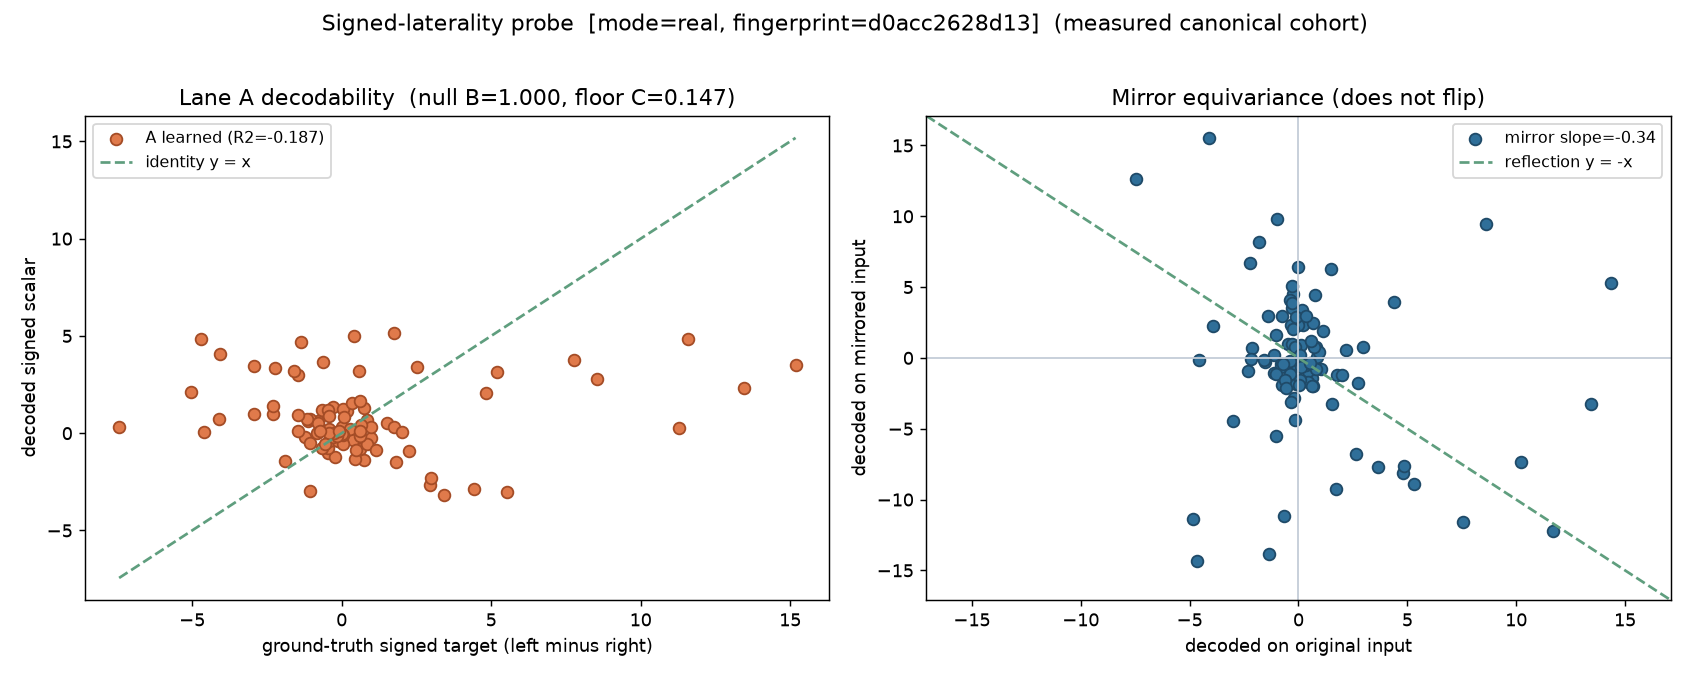

In [11]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image as IPythonImage, display

OUT_DIR = ARTIFACT_ROOT / MODE
OUT_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))

# Panel 1: decodability
if HAVE_TORCH:
    preds = lanes["A_learned"]["preds"]
    ax[0].scatter(y, preds, s=42, c="#e07a4b", edgecolors="#a44c26", label=f"A learned (R2={lanes['A_learned']['r2']:.3f})")
    lo, hi = float(min(y.min(), preds[~np.isnan(preds)].min())), float(max(y.max(), preds[~np.isnan(preds)].max()))
    ax[0].plot([lo, hi], [lo, hi], "--", color="#5f9e7e", label="identity y = x")
    ax[0].set_title(f"Lane A decodability  (null B={lanes['B_raw_null']['r2']:.3f}, floor C={lanes['C_floor']['r2']:.3f})")
else:
    ax[0].text(0.5, 0.5, "Learned lanes need PyTorch", ha="center")
ax[0].set_xlabel("ground-truth signed target (left minus right)")
ax[0].set_ylabel("decoded signed scalar")
ax[0].legend(loc="upper left", fontsize=9)

# Panel 2: mirror
if mirror["available"]:
    ax[1].scatter(mirror["dec_orig"], mirror["dec_mir"], s=42, c="#2f6f99", edgecolors="#1f4a68",
                  label=f"mirror slope={mirror['slope']:+.2f}")
    lim = float(np.abs(np.concatenate([mirror["dec_orig"], mirror["dec_mir"]])).max()) * 1.1
    ax[1].plot([-lim, lim], [lim, -lim], "--", color="#5f9e7e", label="reflection y = -x")
    ax[1].axhline(0, color="#c4cdd8", lw=1); ax[1].axvline(0, color="#c4cdd8", lw=1)
    ax[1].set_xlim(-lim, lim); ax[1].set_ylim(-lim, lim)
    ax[1].set_title("Mirror equivariance " + ("(FLIPS)" if mirror["flips"] else "(does not flip)"))
else:
    ax[1].text(0.5, 0.5, "Mirror needs the encoder", ha="center")
ax[1].set_xlabel("decoded on original input"); ax[1].set_ylabel("decoded on mirrored input")
ax[1].legend(loc="upper right", fontsize=9)

figure_scope = "illustrative smoke fixture" if MODE == "smoke" else "measured canonical cohort"
fig.suptitle(
    f"Signed-laterality probe  [mode={MODE}, fingerprint={FINGERPRINT[:12]}]  ({figure_scope})",
    fontsize=12,
)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig_path = OUT_DIR / "idea5_signed_laterality_probe.png"
fig.savefig(fig_path, dpi=130)
print(f"saved figure: {fig_path}")
# Display the exact PNG that was written, even with the non-interactive Agg backend.
display(IPythonImage(filename=str(fig_path)))
plt.close(fig)

## 11. Persist the result bundle

We write a small JSON bundle (verdict, per-lane R-squared and MAE, the mirror slope, the fingerprint,
the fold count, and the cohort counts) next to the other artifacts. This is the machine-readable record
the methodology document and the README point at, and the input the futures notebook (05b) compares
real outcomes against.

In [12]:
bundle = {
    "notebook": "nb_05a_signed_laterality_probe",
    "mode": MODE,
    "fingerprint": FINGERPRINT,
    "n_sequences": int(len(records)),
    "n_sources": int(n_groups),
    "n_splits": int(n_splits),
    "condition_counts": meta.groupby("condition").size().to_dict(),
    "lanes": {k: {"r2": v["r2"], "mae": v["mae"]} for k, v in lanes.items()},
    "mirror": {"slope": mirror.get("slope"), "flips": mirror.get("flips")},
    "verdict": verdict,
    "transductive": True,
    "notes": "All results transductive; source video is the independent unit; folder labels are dataset annotations, not diagnoses.",
}
bundle_path = OUT_DIR / "idea5_signed_laterality_result.json"
bundle_path.write_text(json.dumps(bundle, indent=2))
print(f"wrote {bundle_path}")
print(json.dumps({k: bundle[k] for k in ("mode", "fingerprint", "n_sequences", "n_sources", "verdict")}, indent=2)[:900])

wrote /Users/pmui/dev/alexpose/experiments/sjepa/gavd5/work/artifacts/real/idea5_signed_laterality_result.json
{
  "mode": "real",
  "fingerprint": "d0acc2628d134959d8b91e96d5112fc3bed560fe8feb9569e5b13b11a8b614d1",
  "n_sequences": 96,
  "n_sources": 18,
  "verdict": {
    "mode": "real",
    "fingerprint": "d0acc2628d134959d8b91e96d5112fc3bed560fe8feb9569e5b13b11a8b614d1",
    "A_r2": -0.18713340405489576,
    "B_r2": 0.9999999991665892,
    "C_r2": 0.14713846965336574,
    "D_r2": -0.014068432701038303,
    "sign_consistency": 0.5,
    "beats_floor_by_0.05": false,
    "reaches_80pct_of_null": false,
    "sign_consistent_75pct": false,
    "mirror_slope": -0.3426603346171674,
    "mirror_flips": false,
    "PRIMARY_VERDICT": "INFORMATIVE NULL",
    "D_control_ok": true
  }
}


## 12. Discussion: what the observed results mean

The next cell walks through the measured result one decision at a time. It explains the statistics in ordinary language, identifies the strongest and weakest parts of the evidence, and separates the licensed conclusion from broader claims that this experiment cannot support.


In [13]:
from IPython.display import Markdown, display

if HAVE_TORCH:
    a = verdict["A_r2"]
    b = verdict["B_r2"]
    c = verdict["C_r2"]
    d = verdict["D_r2"]
    floor_margin = 0.05
    null_fraction = 0.80
    sign_threshold = 0.75
    mirror_band = (-1.25, -0.8)
    floor_gap = a - c
    required_floor = c + floor_margin
    required_null = null_fraction * b
    discussion_markdown = f"""
### Step 1: restate the question

This experiment asks a narrow representation question: **can a simple weighted sum recover one left-minus-right motion number from features made by the already-trained encoder, on source videos that were withheld while that weighted sum was fitted?** This simple weighted sum is the linear probe or readout. The encoder is frozen, meaning none of its learned weights change here. The experiment is not asking whether raw pose coordinates contain laterality; Lane B checks that separately.

### Step 2: understand why four lanes are needed

- **Lane A, learned encoder:** this is the hypothesis under test. A strong result would mean the frozen learned features place the signed number where a simple readout can reach it.
- **Lane B, raw-coordinate ceiling:** this fits the same kind of simple readout directly to coordinate summaries. It checks that the target can in fact be recovered from the input information used to define it. Because the target is built as a linear sum of these signed movement summaries, an R-squared near 1 is expected. This lane validates the target and scoring path; it does not show that the encoder learned anything.
- **Lane C, untrained-encoder floor:** this uses an encoder with random, never-trained weights but the same shape as the learned encoder. It measures how much apparent prediction can arise from architecture, dimensionality, and accidental structure even without representation learning. Lane A must beat this floor by a fixed amount.
- **Lane D, side-agnostic nuisance control:** this deliberately forgets which joints are left and which are right by reducing them to global averages and standard deviations. If Lane D predicted well, the probe might be using overall movement size, video style, or pose-detector behavior instead of a genuine signed left/right distinction.

### Step 3: read the observed R-squared values

The measured values were Lane A `{a:.3f}`, Lane B `{b:.3f}`, Lane C `{c:.3f}`, and Lane D `{d:.3f}`. R-squared compares a model with the simple baseline of always predicting the held-out target average. A value of 1 means essentially perfect predictions, 0 means no improvement over repeatedly predicting that average, and a negative value means the model's squared errors are larger than the average-only baseline's errors. It does **not** mean the body moved in a negative direction. Lane A's `{a:.3f}` is therefore not merely small; on these source-disjoint predictions it is worse than predicting one constant average.

Lane B's `{b:.3f}` shows that the signed target is present in the raw coordinate construction. Lane C's `{c:.3f}` is above zero, meaning random high-dimensional token features plus ridge regression recover some structure on these folds. That makes comparison with Lane C essential: comparing Lane A only with zero would miss the fact that the trained representation performed worse than the untrained floor.

### Step 4: apply the three pre-registered gates

A gate is a minimum requirement fixed before the result was inspected. Each gate answers a different failure possibility:

1. **Gate 1 — beat the untrained floor.** Purpose: show that training the encoder added useful linearly readable information beyond what random features already provide. Lane A needed at least `{required_floor:.3f}` because Lane C was `{c:.3f}` and the fixed improvement margin was `{floor_margin:.2f}`. Lane A was `{a:.3f}`, a gap of `{floor_gap:.3f}` relative to Lane C. It did not reach the minimum, so Gate 1 failed.
2. **Gate 2 — approach the raw-coordinate ceiling.** Purpose: require the learned features to preserve a substantial part of a target that the original coordinates can express. Lane A needed at least `{required_null:.3f}`, which is `{null_fraction:.0%}` of Lane B. It reached `{a:.3f}`. It did not reach that minimum, so Gate 2 failed by a wide margin.
3. **Gate 3 — preserve the positive-or-negative direction across held-out sources.** Purpose: prevent a favorable average score from hiding predictions whose left-versus-right direction changes unreliably from video to video. Correct sign was required on at least `{sign_threshold:.0%}` of held-out source videos. The observed fraction was `{verdict['sign_consistency']:.0%}`. It did not reach that minimum, so Gate 3 failed. A 50% value is compatible with an unstable direction and does not support a dependable left-versus-right readout.

The primary claim requires all three gates together. Failing all three makes the informative-null verdict unambiguous under the registered rule.

### Step 5: inspect the mirror mechanism

For each sequence, **decoded-original** is Lane A's prediction from the ordinary pose. **Decoded-mirrored** is the same readout's prediction after horizontal `x` values are negated and all matching left/right landmark identities are swapped. No separate mirror decoder is trained. If an ordinary pose decodes to `+2`, its mirror should decode to about `-2`; if it decodes to `-3`, its mirror should decode to about `+3`. Across all sequences this equal-size, opposite-sign rule produces a decoded-mirrored-versus-decoded-original slope near `-1`, called antisymmetry. The accepted slope band was `{mirror_band}`. The observed slope was `{verdict['mirror_slope']:+.3f}`, outside that band, so the decoded axis did not reverse consistently enough to pass the mirror test. This agrees with the weak decodability result rather than rescuing it. The mirror probe was refitted on all available sources to inspect transformation geometry, so this is a secondary mechanism check, not a held-out prediction-performance estimate.

### Step 6: use the nuisance control correctly

Lane D was `{d:.3f}`, which satisfies the nuisance-control rule. Here, a nuisance is an unwanted shortcut such as total movement amount or video-specific style. Lane D is side-agnostic: it uses global averages and standard deviations but deliberately lacks explicit left-versus-right joint identity. A clean control means this deliberately handicapped lane stays near zero or far below the raw-coordinate reference, as expected. That rules out one pre-specified failure mode in which a supposedly signed result can be predicted without knowing left from right. A clean negative control does **not** turn Lane A into a positive result, prove the full pipeline artifact-free, or repair any failed gate; it only says the result is not the particular F4 nuisance pattern.

### Step 7: consider limitations before generalizing

- **High-dimensional limitation:** the learned feature vector has 1,152 columns for only `{len(y)}` sequences, drawn from even fewer independent source videos. In everyday terms, the probe has many possible numerical knobs but relatively few independent examples from which to set them. Several columns also carry nearly overlapping information; this is collinearity. Standardization, ridge regularization, and choosing the ridge strength only inside training folds reduce extreme fitting, but they cannot manufacture more independent videos. The recorded ill-conditioned-matrix warnings confirm that the numerical problem is difficult. Solver-sensitivity and dimensionality-reduction checks would show how much the exact score changes when that many-knobs problem is handled differently.
- **Transductive limitation:** the ridge folds hold out source videos from the probe, so those videos do not teach the final weighted sum. However, the frozen encoder was trained earlier on this same corpus. Imagine a student who studies all the cards before some are separated into a quiz: the final answer rule is tested on held-out cards, but the representation-maker has still seen the collection. The result therefore cannot support a claim about a completely unseen video, person, hospital, or dataset. A stronger test would train the encoder itself without the held-out people or sources.
- This is a linear probe of one chosen token construction. A null means the axis is not linearly exposed through this representation and readout; it does not prove that no nonlinear function, other layer, or alternative temporal summary could recover laterality.
- Lane B is almost exact partly because the target is explicitly constructed from the same family of raw signed-excursion measurements. It is a fair ceiling for this target, not an independent biological ground truth.
- Eighteen source videos remain a small independent-unit count. The experiment reports a registered threshold decision, not a precise population effect with stable confidence intervals.

### Step 8: identify the useful next experiments

The highest-value follow-ups are to repeat the probe with a numerically stable ridge solver and sensitivity analysis, test pre-registered alternative layers or temporal summaries without moving the current decision threshold, and fit the entire representation-learning pipeline inside source- or participant-disjoint folds. A real multi-view cohort would then test whether any recovered axis stays stable across viewpoints and flips under a genuine left/right view change.

### Discussion conclusion

The result is informative because the raw target is recoverable, the nuisance control behaves correctly, and the trained representation still fails every primary gate and the mirror test. The most direct interpretation is that this frozen checkpoint has **not organized the tested signed laterality quantity into a robust linearly accessible, reflection-antisymmetric axis**. This is a useful negative representation audit, not a clinical or universal statement about laterality.
"""
else:
    discussion_markdown = """
### Discussion unavailable

PyTorch was unavailable, so the learned, untrained, nuisance, and mirror lanes did not run. The raw-coordinate check alone cannot answer the signed-representation question.
"""

display(Markdown(discussion_markdown))



### Step 1: restate the question

This experiment asks a narrow representation question: **can a simple weighted sum recover one left-minus-right motion number from features made by the already-trained encoder, on source videos that were withheld while that weighted sum was fitted?** This simple weighted sum is the linear probe or readout. The encoder is frozen, meaning none of its learned weights change here. The experiment is not asking whether raw pose coordinates contain laterality; Lane B checks that separately.

### Step 2: understand why four lanes are needed

- **Lane A, learned encoder:** this is the hypothesis under test. A strong result would mean the frozen learned features place the signed number where a simple readout can reach it.
- **Lane B, raw-coordinate ceiling:** this fits the same kind of simple readout directly to coordinate summaries. It checks that the target can in fact be recovered from the input information used to define it. Because the target is built as a linear sum of these signed movement summaries, an R-squared near 1 is expected. This lane validates the target and scoring path; it does not show that the encoder learned anything.
- **Lane C, untrained-encoder floor:** this uses an encoder with random, never-trained weights but the same shape as the learned encoder. It measures how much apparent prediction can arise from architecture, dimensionality, and accidental structure even without representation learning. Lane A must beat this floor by a fixed amount.
- **Lane D, side-agnostic nuisance control:** this deliberately forgets which joints are left and which are right by reducing them to global averages and standard deviations. If Lane D predicted well, the probe might be using overall movement size, video style, or pose-detector behavior instead of a genuine signed left/right distinction.

### Step 3: read the observed R-squared values

The measured values were Lane A `-0.187`, Lane B `1.000`, Lane C `0.147`, and Lane D `-0.014`. R-squared compares a model with the simple baseline of always predicting the held-out target average. A value of 1 means essentially perfect predictions, 0 means no improvement over repeatedly predicting that average, and a negative value means the model's squared errors are larger than the average-only baseline's errors. It does **not** mean the body moved in a negative direction. Lane A's `-0.187` is therefore not merely small; on these source-disjoint predictions it is worse than predicting one constant average.

Lane B's `1.000` shows that the signed target is present in the raw coordinate construction. Lane C's `0.147` is above zero, meaning random high-dimensional token features plus ridge regression recover some structure on these folds. That makes comparison with Lane C essential: comparing Lane A only with zero would miss the fact that the trained representation performed worse than the untrained floor.

### Step 4: apply the three pre-registered gates

A gate is a minimum requirement fixed before the result was inspected. Each gate answers a different failure possibility:

1. **Gate 1 — beat the untrained floor.** Purpose: show that training the encoder added useful linearly readable information beyond what random features already provide. Lane A needed at least `0.197` because Lane C was `0.147` and the fixed improvement margin was `0.05`. Lane A was `-0.187`, a gap of `-0.334` relative to Lane C. It did not reach the minimum, so Gate 1 failed.
2. **Gate 2 — approach the raw-coordinate ceiling.** Purpose: require the learned features to preserve a substantial part of a target that the original coordinates can express. Lane A needed at least `0.800`, which is `80%` of Lane B. It reached `-0.187`. It did not reach that minimum, so Gate 2 failed by a wide margin.
3. **Gate 3 — preserve the positive-or-negative direction across held-out sources.** Purpose: prevent a favorable average score from hiding predictions whose left-versus-right direction changes unreliably from video to video. Correct sign was required on at least `75%` of held-out source videos. The observed fraction was `50%`. It did not reach that minimum, so Gate 3 failed. A 50% value is compatible with an unstable direction and does not support a dependable left-versus-right readout.

The primary claim requires all three gates together. Failing all three makes the informative-null verdict unambiguous under the registered rule.

### Step 5: inspect the mirror mechanism

For each sequence, **decoded-original** is Lane A's prediction from the ordinary pose. **Decoded-mirrored** is the same readout's prediction after horizontal `x` values are negated and all matching left/right landmark identities are swapped. No separate mirror decoder is trained. If an ordinary pose decodes to `+2`, its mirror should decode to about `-2`; if it decodes to `-3`, its mirror should decode to about `+3`. Across all sequences this equal-size, opposite-sign rule produces a decoded-mirrored-versus-decoded-original slope near `-1`, called antisymmetry. The accepted slope band was `(-1.25, -0.8)`. The observed slope was `-0.343`, outside that band, so the decoded axis did not reverse consistently enough to pass the mirror test. This agrees with the weak decodability result rather than rescuing it. The mirror probe was refitted on all available sources to inspect transformation geometry, so this is a secondary mechanism check, not a held-out prediction-performance estimate.

### Step 6: use the nuisance control correctly

Lane D was `-0.014`, which satisfies the nuisance-control rule. Here, a nuisance is an unwanted shortcut such as total movement amount or video-specific style. Lane D is side-agnostic: it uses global averages and standard deviations but deliberately lacks explicit left-versus-right joint identity. A clean control means this deliberately handicapped lane stays near zero or far below the raw-coordinate reference, as expected. That rules out one pre-specified failure mode in which a supposedly signed result can be predicted without knowing left from right. A clean negative control does **not** turn Lane A into a positive result, prove the full pipeline artifact-free, or repair any failed gate; it only says the result is not the particular F4 nuisance pattern.

### Step 7: consider limitations before generalizing

- **High-dimensional limitation:** the learned feature vector has 1,152 columns for only `96` sequences, drawn from even fewer independent source videos. In everyday terms, the probe has many possible numerical knobs but relatively few independent examples from which to set them. Several columns also carry nearly overlapping information; this is collinearity. Standardization, ridge regularization, and choosing the ridge strength only inside training folds reduce extreme fitting, but they cannot manufacture more independent videos. The recorded ill-conditioned-matrix warnings confirm that the numerical problem is difficult. Solver-sensitivity and dimensionality-reduction checks would show how much the exact score changes when that many-knobs problem is handled differently.
- **Transductive limitation:** the ridge folds hold out source videos from the probe, so those videos do not teach the final weighted sum. However, the frozen encoder was trained earlier on this same corpus. Imagine a student who studies all the cards before some are separated into a quiz: the final answer rule is tested on held-out cards, but the representation-maker has still seen the collection. The result therefore cannot support a claim about a completely unseen video, person, hospital, or dataset. A stronger test would train the encoder itself without the held-out people or sources.
- This is a linear probe of one chosen token construction. A null means the axis is not linearly exposed through this representation and readout; it does not prove that no nonlinear function, other layer, or alternative temporal summary could recover laterality.
- Lane B is almost exact partly because the target is explicitly constructed from the same family of raw signed-excursion measurements. It is a fair ceiling for this target, not an independent biological ground truth.
- Eighteen source videos remain a small independent-unit count. The experiment reports a registered threshold decision, not a precise population effect with stable confidence intervals.

### Step 8: identify the useful next experiments

The highest-value follow-ups are to repeat the probe with a numerically stable ridge solver and sensitivity analysis, test pre-registered alternative layers or temporal summaries without moving the current decision threshold, and fit the entire representation-learning pipeline inside source- or participant-disjoint folds. A real multi-view cohort would then test whether any recovered axis stays stable across viewpoints and flips under a genuine left/right view change.

### Discussion conclusion

The result is informative because the raw target is recoverable, the nuisance control behaves correctly, and the trained representation still fails every primary gate and the mirror test. The most direct interpretation is that this frozen checkpoint has **not organized the tested signed laterality quantity into a robust linearly accessible, reflection-antisymmetric axis**. This is a useful negative representation audit, not a clinical or universal statement about laterality.


## 13. Outcome of the signed-laterality experiment

This final cell converts the pre-registered checks into one plain-language conclusion. It is generated from the current run's `verdict` dictionary so it remains accurate if the notebook is rerun with a different mode or checkpoint.


In [14]:
from IPython.display import Markdown, display

if HAVE_TORCH:
    failed_checks = [
        label for label, passed_check in [
            ("beat the untrained floor by at least 0.05 R-squared", verdict["beats_floor_by_0.05"]),
            ("reach at least 80% of the raw-coordinate ceiling", verdict["reaches_80pct_of_null"]),
            ("get the decoded sign right on at least 75% of held-out sources", verdict["sign_consistent_75pct"]),
        ] if not passed_check
    ]
    gate_text = (
        "The failed primary checks were: " + "; ".join(failed_checks) + "."
        if failed_checks else
        "All three primary checks passed."
    )
    mirror_text = (
        "inside" if verdict.get("mirror_flips") else "outside"
    )
    a_r2_meaning = (
        "worse than always predicting the held-out average"
        if verdict["A_r2"] < 0 else
        "no better than always predicting the held-out average"
        if abs(verdict["A_r2"]) < 1e-12 else
        "better than the held-out-average fallback, although the gates still determine the verdict"
    )
    d_control_text = (
        "passed: the side-agnostic summaries stayed low enough not to trigger the planned shortcut warning"
        if verdict["D_control_ok"] else
        "failed: side-agnostic summaries predicted too well, so an unwanted shortcut may explain the result"
    )
    mode_warning = (
        "**This is a smoke-mode plumbing result, not the frozen real-checkpoint result.**"
        if MODE == "smoke" else
        "**This is the measured result for the frozen real checkpoint and canonical cohort used by this run.**"
    )
    outcome_markdown = f"""
### Primary verdict: **{verdict['PRIMARY_VERDICT']}**

{mode_warning}

- **Learned Lane A:** R-squared `{verdict['A_r2']:.3f}`; this is {a_r2_meaning}.
- **Raw-coordinate Lane B:** R-squared `{verdict['B_r2']:.3f}`. This is the fair coordinate-level ceiling because the frozen target is constructed from signed coordinate excursions.
- **Untrained-encoder Lane C:** R-squared `{verdict['C_r2']:.3f}`.
- **Side-agnostic nuisance Lane D:** R-squared `{verdict['D_r2']:.3f}`; the control {d_control_text}.
- **Held-out-source sign consistency:** `{verdict['sign_consistency']:.1%}` of source videos had the correct positive-or-negative direction.
- **Mirror slope:** `{verdict['mirror_slope']:+.3f}`, which is {mirror_text} the pre-registered flip band `[-1.25, -0.8]`. A slope near `-1` would mean, for example, that decoded-original `+2` becomes decoded-mirrored `-2`. Mirror test passed: `{verdict['mirror_flips']}`.

A gate is a pre-agreed minimum requirement. {gate_text} The nuisance control stayed near zero, so this is not the specific artifact case in which side-agnostic pooling appears to recover a signed axis. A clean control removes that one shortcut explanation; it does not override a failed primary gate.

**Licensed conclusion.** Under this pre-registered linear probe, with whole source videos kept out of each probe-fitting fold, the frozen encoder does not expose the tested signed laterality axis strongly enough to pass the three gates. Its decoded-mirrored output also does not become the equal-size opposite of decoded-original. This is an informative null for the proposed simple linear signed-axis hypothesis: the planned test produced an interpretable negative answer. It does not prove that laterality is absent from the input, absent from every model layer, or impossible to recover with a more complicated rule. Because the encoder learned from this corpus before the probe split, the analysis is transductive and is not evidence about diagnosis or performance on a genuinely unseen patient or dataset.
"""
else:
    outcome_markdown = """
### Outcome unavailable

The encoder-dependent lanes and mirror test were skipped because PyTorch was unavailable. Only the raw-coordinate plumbing ran, so this notebook cannot issue the pre-registered signed-axis verdict.
"""

display(Markdown(outcome_markdown))



### Primary verdict: **INFORMATIVE NULL**

**This is the measured result for the frozen real checkpoint and canonical cohort used by this run.**

- **Learned Lane A:** R-squared `-0.187`; this is worse than always predicting the held-out average.
- **Raw-coordinate Lane B:** R-squared `1.000`. This is the fair coordinate-level ceiling because the frozen target is constructed from signed coordinate excursions.
- **Untrained-encoder Lane C:** R-squared `0.147`.
- **Side-agnostic nuisance Lane D:** R-squared `-0.014`; the control passed: the side-agnostic summaries stayed low enough not to trigger the planned shortcut warning.
- **Held-out-source sign consistency:** `50.0%` of source videos had the correct positive-or-negative direction.
- **Mirror slope:** `-0.343`, which is outside the pre-registered flip band `[-1.25, -0.8]`. A slope near `-1` would mean, for example, that decoded-original `+2` becomes decoded-mirrored `-2`. Mirror test passed: `False`.

A gate is a pre-agreed minimum requirement. The failed primary checks were: beat the untrained floor by at least 0.05 R-squared; reach at least 80% of the raw-coordinate ceiling; get the decoded sign right on at least 75% of held-out sources. The nuisance control stayed near zero, so this is not the specific artifact case in which side-agnostic pooling appears to recover a signed axis. A clean control removes that one shortcut explanation; it does not override a failed primary gate.

**Licensed conclusion.** Under this pre-registered linear probe, with whole source videos kept out of each probe-fitting fold, the frozen encoder does not expose the tested signed laterality axis strongly enough to pass the three gates. Its decoded-mirrored output also does not become the equal-size opposite of decoded-original. This is an informative null for the proposed simple linear signed-axis hypothesis: the planned test produced an interpretable negative answer. It does not prove that laterality is absent from the input, absent from every model layer, or impossible to recover with a more complicated rule. Because the encoder learned from this corpus before the probe split, the analysis is transductive and is not evidence about diagnosis or performance on a genuinely unseen patient or dataset.
